# PTM for OpenMMD - File Input

In [3]:
# Load files
LIGsdf = "/home/cwagner/openmmdl_ptm/OpenMMDL/openmmdl_ptm/maleimide.sdf"
PROTLIGpdb = "/home/cwagner/openmmdl_ptm/OpenMMDL/openmmdl_ptm/3ip9_dye.pdb"

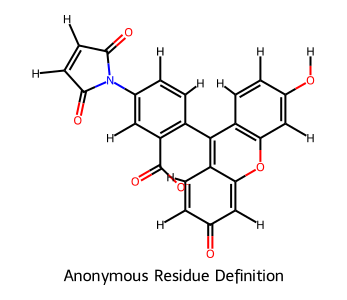

In [63]:
# Read Ligand from sdf
from openff.pablo import ResidueDefinition

LIGresdef = ResidueDefinition.anon_from_sdf(LIGsdf)
LIGresdef.visualize()

In [64]:
# Get Ligand Smarts
from rdkit import Chem

mol = Chem.SDMolSupplier(LIGsdf)

LIGsmiles = Chem.MolToSmiles(mol[0])
# SMILES als SMARTS-Pattern verwenden (exakter Match)
LIGsmarts = Chem.MolToSmarts(mol[0])
print(LIGsmiles, '->', LIGsmarts)

O=C([O-])c1cc(N2C(=O)C=CC2=O)ccc1-c1c2ccc(=O)cc-2oc2cc(O)ccc12 -> [#6]1=[#6]-[#6](=[#8])-[#7](-[#6]2:[#6]:[#6]:[#6](-[#6]3:[#6]4:[#6]:[#6]:[#6](=[#8]):[#6]:[#6]-4:[#8]:[#6]4:[#6]:[#6](-[#8]):[#6]:[#6]:[#6]:3:4):[#6](-[#6](=[#8])-[#8-]):[#6]:2)-[#6]-1=[#8]


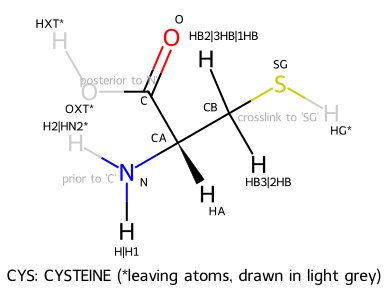

In [65]:
# Read Residue from PROTLIG.pdb
# Später automatisch aus .pdb auslesen
# Jetzt placeholder - Cys vordefiniert

from openff.pablo import STD_CCD_CACHE

RESname = "CYS"

RESresdef = STD_CCD_CACHE[RESname][0]
RESresdef.visualize()

In [66]:
# Get Residue Smarts
# From the CCD cache

from rdkit import Chem

RESmol = RESresdef.to_openff_molecule()
RESsmiles = RESmol.to_smiles()
RESrdmol = RESmol.to_rdkit()
RESsmarts = Chem.MolToSmarts(RESrdmol)
print(RESsmiles, '->', RESsmarts)


[H][O][C](=[O])[C@@]([H])([N]([H])[H])[C]([H])([H])[S][H] -> [#7](-[#6@](-[#6](=[#8])-[#8]-[H])(-[#6](-[#16]-[H])(-[H])-[H])-[H])(-[H])-[H]


In [75]:
# Get PTM smiles 
import MDAnalysis as mda
import prolif as plf

# ptm res name
ligNAME = "DYE"

# Load files
LIGsdf = "/home/cwagner/openmmdl_ptm/OpenMMDL/openmmdl_ptm/maleimide.sdf"
PROTLIGpdb = "/home/cwagner/openmmdl_ptm/OpenMMDL/openmmdl_ptm/3ip9_dye.pdb"

# load topology and trajectory
u = mda.Universe(PROTLIGpdb)

# create selections for the ligand and protein
ligand_selection = u.select_atoms(f"resname {ligNAME}")

# create a molecule from the MDAnalysis selection
ligand_mol = plf.Molecule.from_mda(ligand_selection)
# display
plf.display_residues(ligand_mol, size=(400, 200))

# Smiles from ligand_selection
from rdkit import Chem
PTMsmiles = Chem.MolToSmiles(ligand_mol)
print(PTMsmiles)




[H][N][C@]([H])([C]=O)C([H])([H])S[C@]1([H])C(=O)N(c2c([H])c([H])c(-c3c4c([H])c([H])c(=O)c([H])c-4oc4c([H])c(O[H])c([H])c([H])c34)c(C(=O)[O-])c2[H])C(=O)C1([H])[H]


In [32]:
# Doppelbindungen in 

## Heavy Atoms gemappt, hydrogens nicht gemappt -> Fehler

In [76]:
# Map LIGsmarts and RESsmarts to PTMsmarts bzw. LIGsmiles and RESsmiles to PTMsmiles
# 1) Automatische Reaction-Mapper (nur für bekannte organische Reaktionen) https://github.com/rxn4chemistry/rxnmapper

import pkg_resources
from rxnmapper import RXNMapper
rxn_mapper = RXNMapper()
rxns = [f"{LIGsmiles}.{RESsmiles}>>{PTMsmiles}"]
RXNsmiles = rxn_mapper.get_attention_guided_atom_maps(rxns)
print(RXNsmiles)

def split_smarts(smarts: str):
    reactants, products = smarts.split('>>')
    reactant_smarts = reactants.split('.')
    product_smarts = products.split('.')
    return reactant_smarts, product_smarts

reactant_smiles, product_smiles = split_smarts(RXNsmiles[0]["mapped_rxn"])
# print(reactant_smiles)
# print(product_smiles)

LIGsmiles = reactant_smiles[1]
RESsmiles = reactant_smiles[0]
PTMsmiles = product_smiles[0]

print(f"LIGsmiles: {LIGsmiles}")
print(f"RESsmiles: {RESsmiles}")
print(f"PTMsmiles: {PTMsmiles}")


[{'confidence': 0.5120592201619116, 'mapped_rxn': 'O=[C:3]([C@@H:2]([NH2:1])[CH2:5][SH:6])[OH:4].[CH:7]1=[CH:8][C:9](=[O:10])[N:11]([c:12]2[cH:13][cH:14][c:15](-[c:16]3[c:17]4[cH:18][cH:19][c:20](=[O:21])[cH:22][c:23]-4[o:24][c:25]4[cH:26][c:27]([OH:28])[cH:29][cH:30][c:31]34)[c:32]([C:33](=[O:34])[O-:35])[cH:36]2)[C:37]1=[O:38]>>[NH:1][C@H:2]([C:3]=[O:4])[CH2:5][S:6][C@H:7]1[CH2:8][C:9](=[O:10])[N:11]([c:12]2[cH:13][cH:14][c:15](-[c:16]3[c:17]4[cH:18][cH:19][c:20](=[O:21])[cH:22][c:23]-4[o:24][c:25]4[cH:26][c:27]([OH:28])[cH:29][cH:30][c:31]34)[c:32]([C:33](=[O:34])[O-:35])[cH:36]2)[C:37]1=[O:38]'}]
LIGsmiles: [CH:7]1=[CH:8][C:9](=[O:10])[N:11]([c:12]2[cH:13][cH:14][c:15](-[c:16]3[c:17]4[cH:18][cH:19][c:20](=[O:21])[cH:22][c:23]-4[o:24][c:25]4[cH:26][c:27]([OH:28])[cH:29][cH:30][c:31]34)[c:32]([C:33](=[O:34])[O-:35])[cH:36]2)[C:37]1=[O:38]
RESsmiles: O=[C:3]([C@@H:2]([NH2:1])[CH2:5][SH:6])[OH:4]
PTMsmiles: [NH:1][C@H:2]([C:3]=[O:4])[CH2:5][S:6][C@H:7]1[CH2:8][C:9](=[O:10])[N:11]([c:12

In [77]:
# Define new PTM Residue
PTMresdef = ResidueDefinition.react(
    reactants=[RESresdef, LIGresdef],
    reactant_smarts = [
        RESsmiles,
        LIGsmiles,
    ],
    product_smarts = [
        PTMsmiles,
    ],
)[0][0] # Returns a list of tuples, we want the first (and only) element of any (identical) tuple
PTMresdef.visualize()

AssertionError: 

## Idee: Hydrogens hinzufügen und dann mappen
-> Leider kann rxnmapper keine Hydrogens mappen

In [82]:
LIGmol = Chem.MolFromSmiles(LIGsmiles)
LIGmol = Chem.AddHs(LIGmol)
LIGsmiles = Chem.MolToSmiles(LIGmol)
print(LIGsmiles)

RESmol = Chem.MolFromSmiles(RESsmiles)
RESmol = Chem.AddHs(RESmol)
RESsmiles = Chem.MolToSmiles(RESmol)

PTMmol = Chem.MolFromSmiles(PTMsmiles)
PTMmol = Chem.AddHs(PTMmol)
PTMsmiles = Chem.MolToSmiles(PTMmol)


[H][C:4]1=[C:5]([H])[C:6](=[O:7])[N:8]([H])[C:9]1=[O:10]


In [83]:
# Map LIGsmarts and RESsmarts to PTMsmarts bzw. LIGsmiles and RESsmiles to PTMsmiles
# 1) Automatische Reaction-Mapper (nur für bekannte organische Reaktionen) https://github.com/rxn4chemistry/rxnmapper

import pkg_resources
from rxnmapper import RXNMapper
rxn_mapper = RXNMapper()
rxns = [f"{LIGsmiles}.{RESsmiles}>>{PTMsmiles}"]
RXNsmiles = rxn_mapper.get_attention_guided_atom_maps(rxns)
print(RXNsmiles)

def split_smarts(smarts: str):
    reactants, products = smarts.split('>>')
    reactant_smarts = reactants.split('.')
    product_smarts = products.split('.')
    return reactant_smarts, product_smarts

reactant_smiles, product_smiles = split_smarts(RXNsmiles[0]["mapped_rxn"])
# print(reactant_smiles)
# print(product_smiles)

LIGsmiles = reactant_smiles[1]
RESsmiles = reactant_smiles[0]
PTMsmiles = product_smiles[0]

print(f"LIGsmiles: {LIGsmiles}")
print(f"RESsmiles: {RESsmiles}")
print(f"PTMsmiles: {PTMsmiles}")


[{'confidence': 0.6475227498429713, 'mapped_rxn': '[CH3:1][CH2:2][SH:3].[CH:4]1=[CH:5][C:6](=[O:7])[NH:8][C:9]1=[O:10]>>[CH3:1][CH2:2][S:3][C@H:4]1[CH2:5][C:6](=[O:7])[NH:8][C:9]1=[O:10]'}]
LIGsmiles: [CH:4]1=[CH:5][C:6](=[O:7])[NH:8][C:9]1=[O:10]
RESsmiles: [CH3:1][CH2:2][SH:3]
PTMsmiles: [CH3:1][CH2:2][S:3][C@H:4]1[CH2:5][C:6](=[O:7])[NH:8][C:9]1=[O:10]


In [84]:
# Define new PTM Residue
PTMresdef = ResidueDefinition.react(
    reactants=[RESresdef, LIGresdef],
    reactant_smarts = [
        RESsmiles,
        LIGsmiles,
    ],
    product_smarts = [
        PTMsmiles,
    ],
)[0][0] # Returns a list of tuples, we want the first (and only) element of any (identical) tuple
PTMresdef.visualize()

AssertionError: 

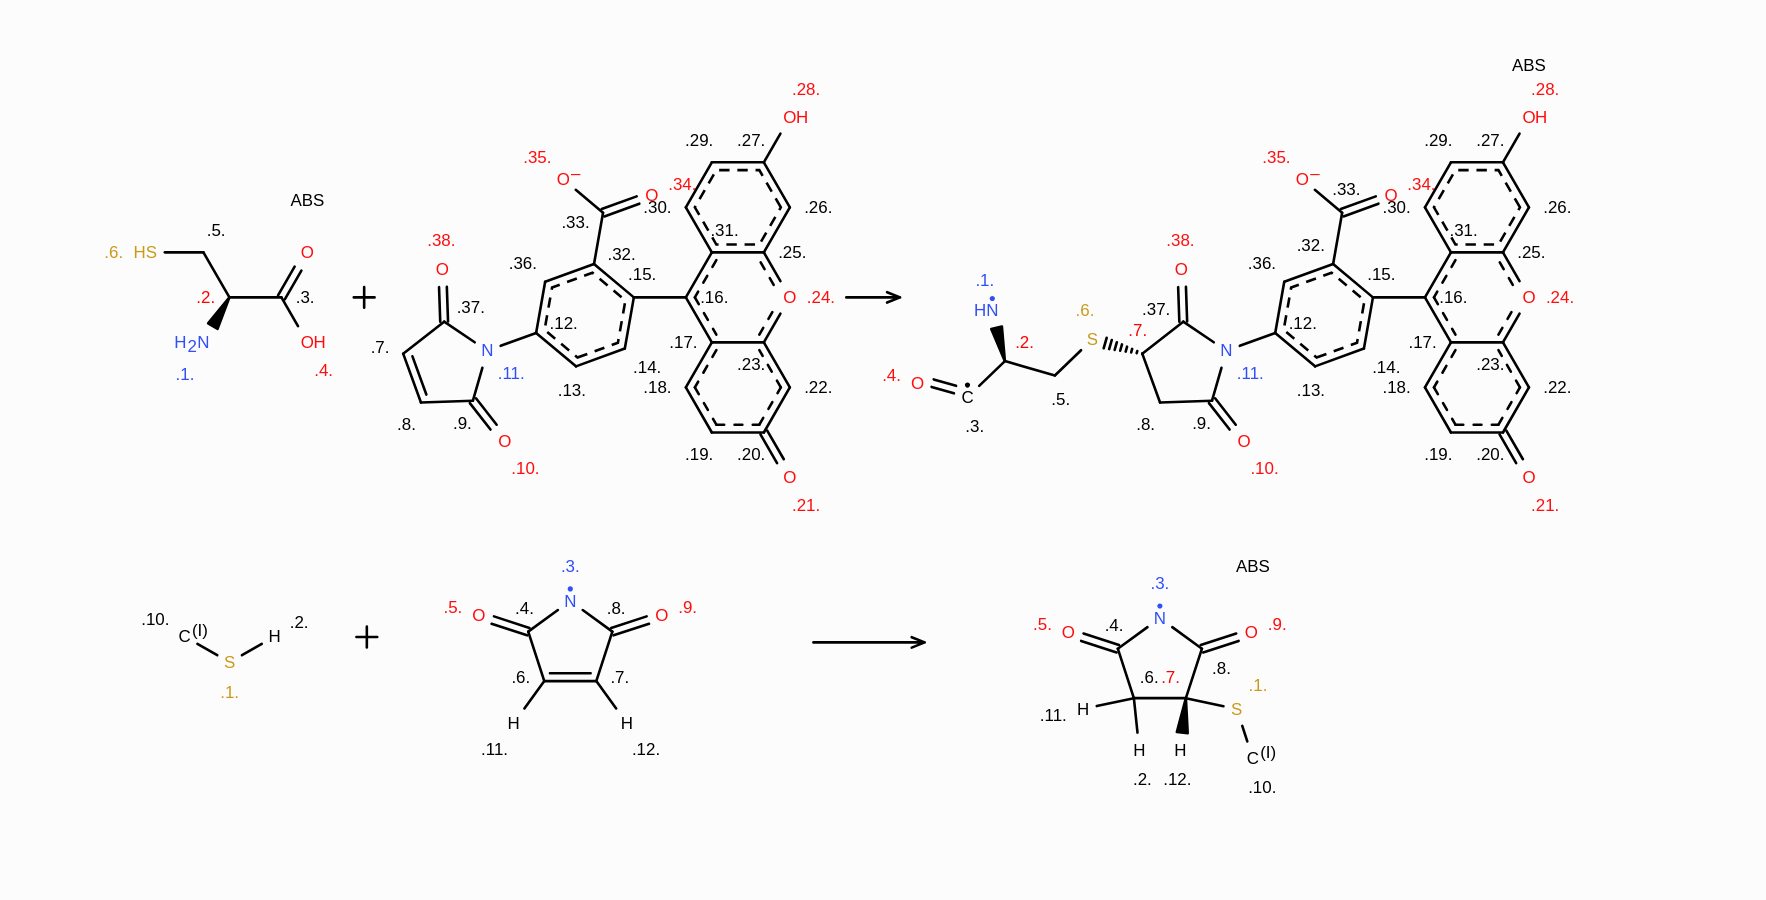